# EDA Project

## Let's take a look at real estate data :).

### Group 5 – The Retired Couple
Situation: Elderly couple looking for peaceful retirement home.

Needs:
- Smaller, cozy home with low maintenance.
- Quiet neighborhood, **near healthcare facilities**.
- Prefer single floor (no stairs).

Task: Find calm, affordable locations. Visualize price vs. square footage to recommend manageable options.

## Hypothesis 

Single-floor homes (floors = 1) are cheaper and more prevalent in certain areas.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#import and clean data
df = pd.read_csv("KC_housing_data.csv")

indices_to_drop = df[df['price'] == 0.0].index

df.drop(indices_to_drop, inplace=True)

df.sort_values(by="price").head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4351,2014-05-06 00:00:00,7800.0,2.0,1.00,780,16344,1.0,0,0,1,780,0,1942,0,4229 S 144th St,Tukwila,WA 98168,USA
1219,2014-05-23 00:00:00,80000.0,1.0,0.75,430,5050,1.0,0,0,2,430,0,1912,0,32215 E Rutherford St,Carnation,WA 98014,USA
1587,2014-05-29 00:00:00,83000.0,2.0,1.00,900,8580,1.0,0,0,3,900,0,1918,0,14440 51st Ave S,Tukwila,WA 98168,USA
4407,2014-05-20 00:00:00,83300.0,3.0,2.00,1490,7770,1.0,0,0,4,1490,0,1990,0,26017 189th Ave SE,Covington,WA 98042,USA
4415,2014-05-23 00:00:00,83300.0,3.0,2.00,1370,78408,1.0,0,0,5,1370,0,1964,0,24007 196th Ave SE,Covington,WA 98042,USA


Mean price of single floor houses: 395000.0
Mean price of multiple floor houses: 548400.0


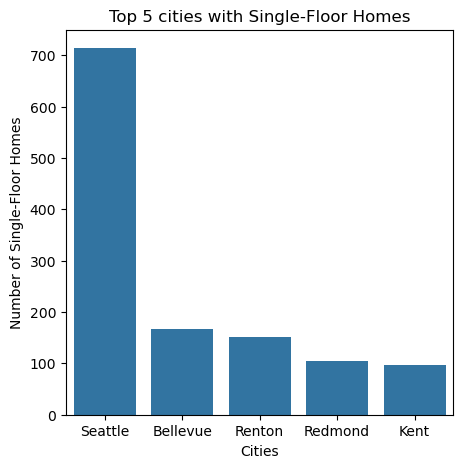

In [ ]:
df['single_floor']= df['floors'] == 1

median_prices = df.groupby('single_floor')['price'].median()
single_mean = median_prices[True] 
multi_mean = median_prices[False] 

print(f'Mean price of single floor houses: {single_mean}')
print(f'Mean price of multiple floor houses: {multi_mean}')

# Visualize price vs. square footage to recommend manageable options
single_floor_df = df[df['floors'] == 1]
city_count = single_floor_df['city'].value_counts().head(5)

plt.figure(figsize=(5 ,5))
sns.barplot(x=city_count.index, 
            y=city_count.values,
            palette=magma)
plt.xlabel("Cities")
plt.ylabel("Number of Single-Floor Homes")
plt.title("Top 5 cities with Single-Floor Homes")
plt.show()

### Price per sqft

Top 10 Cities by Average Price per Square Foot:
city
Beaux Arts Village     500.000000
Medina                 492.127576
Yarrow Point           490.384531
Clyde Hill             429.660737
Mercer Island          362.012606
Seattle                326.417384
Bellevue               323.754916
Kirkland               288.279413
Inglewood-Finn Hill    279.605263
Redmond                278.735000
Name: price_per_sqft, dtype: float64


/var/folders/g7/g4k4lcd13tgd4zgq3y8nyvv80000gn/T/ipykernel_35299/353838221.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_sqft_city.head(10).values,


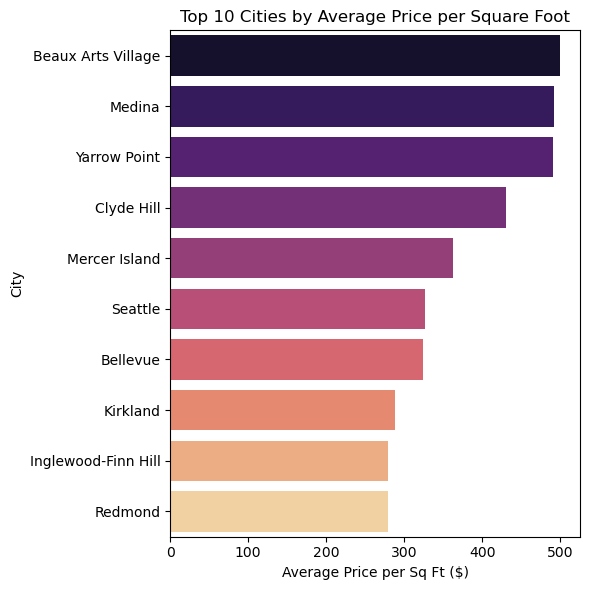

In [13]:
# 1. Calculate price per square foot
# We use 'sqft_living' as it represents the interior living space
df['price_per_sqft'] = df['price'] / df['sqft_living']

# 2. Calculate average price per square foot by city
# We group by city, calculate the mean, and sort the values
avg_price_sqft_city = df.groupby('city')['price_per_sqft'].mean().sort_values(ascending=False)

# 3. Print the top 10 most expensive cities per sq ft
print("Top 10 Cities by Average Price per Square Foot:")
print(avg_price_sqft_city.head(10))

# 4. Visualize the results
plt.figure(figsize=(6, 6))
sns.barplot(x=avg_price_sqft_city.head(10).values, 
            y=avg_price_sqft_city.head(10).index, 
            palette='magma')

plt.title('Top 10 Cities by Average Price per Square Foot')
plt.xlabel('Average Price per Sq Ft ($)')
plt.ylabel('City')
plt.tight_layout()
plt.show()

### Retired Couple Criteria

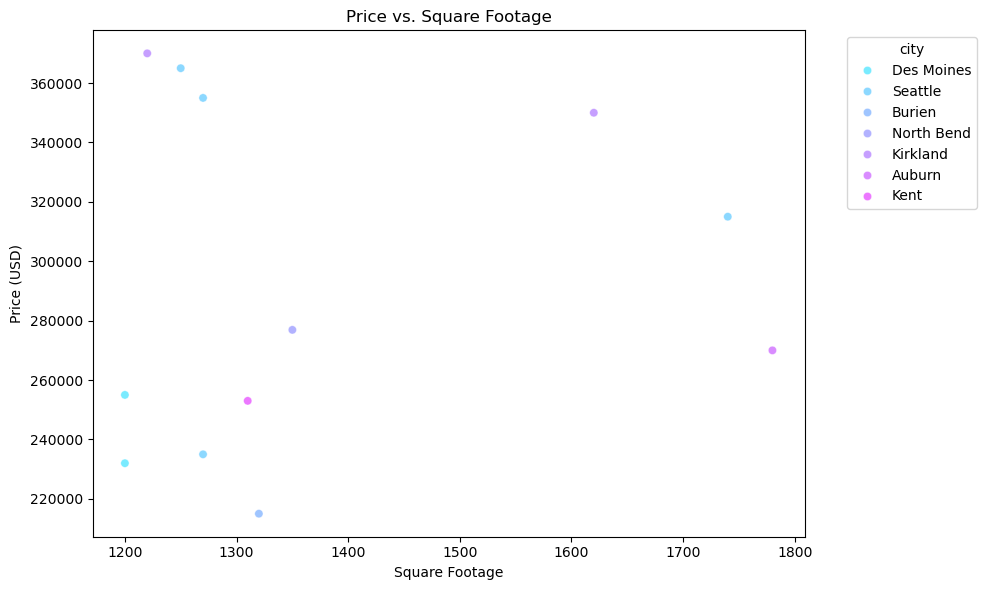

In [11]:
# small to medium houses
cozy_df = single_floor_df[single_floor_df["sqft_living"].between(1200, 2000)]

# affordable housing
affordable_df = cozy_df[cozy_df["price"].between(200000, 400000)]

# number of bedrooms
bedrooms_df = affordable_df[affordable_df["bedrooms"] < 3]

# number of bedrooms
bathrooms_df = bedrooms_df[bedrooms_df["bathrooms"] == 1]

# condition 
good_condition_df = bathrooms_df[bathrooms_df["condition"] >= 4]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=good_condition_df,
    x="sqft_living",
    y="price",
    hue="city",
    palette="cool",
    alpha=0.6
)

plt.title("Price vs. Square Footage")
plt.xlabel("Square Footage")
plt.ylabel("Price (USD)")
plt.legend(title='city', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [12]:
recommended = good_condition_df.sort_values(by="price").head(10)
recommended[["price", "sqft_living", "bedrooms", "bathrooms", "condition", "city", "street"]]

,price,sqft_living,bedrooms,bathrooms,condition,city,street
1423,215000.0,1320,2.0,1.0,4,Burien,2496-2598 S 121st St
89,232000.0,1200,2.0,1.0,4,Des Moines,20220 8th Ave S
349,235000.0,1270,2.0,1.0,4,Seattle,4305 S Webster St
3869,253000.0,1310,2.0,1.0,4,Kent,11414 SE 230th Pl
2121,255000.0,1200,2.0,1.0,5,Des Moines,22018 8th Pl S
3494,270000.0,1780,2.0,1.0,4,Auburn,36816 55th Ave S
2276,276900.0,1350,2.0,1.0,4,North Bend,428 Orchard Ave NE
2215,315000.0,1740,2.0,1.0,4,Seattle,5237 Martin Luther King Jr Way S
2842,350000.0,1620,2.0,1.0,5,Kirkland,12411 84th Ave NE
1485,355000.0,1270,2.0,1.0,4,Seattle,4038 Linden Ave N


### Conclusion

After looking carefully at the first three suggestions, we get that the house "349" is the best option. \
Fits our client's needs and, when looking for the location, the neighborhood looks calm, has a park next to the property and it's close to healthcare facilities.